## 株式銘柄取得

[tickers.txt](./tickers.txt) に記載された銘柄コードを読み込み、Yahoo Finance API で正式なティッカーシンボルに解決する。
国際銘柄が混在していても取引所・出来高をもとに自動判定し、確定した銘柄一覧を `confirmed_df` として保持する。


In [136]:
# ===============================
# Imports
# ===============================
import re
import time
import requests
import pandas as pd
import yfinance as yf

# ===============================
# User Settings
# ===============================
USER_COUNTRY     = "JP"  # ./benchmarks.json5
TICKER_FILE      = "./tickers.txt"
SEARCH_COUNT     = 30
REQUEST_INTERVAL = 0.3

# ===============================
# Yahoo Finance API
# ===============================
YAHOO_SEARCH_URL = "https://query2.finance.yahoo.com/v1/finance/search"

HEADERS = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json",
    "Accept-Language": "en-US,en;q=0.9",
}


In [137]:
# ===============================
# Finance API Cache
# ===============================
_finance_search_cache: dict[str, list[dict]] = {}

def yahoo_finance_search(query: str, count: int = 30) -> list[dict]:
    """Yahoo Finance API search with cache + exponential backoff"""
    query = query.strip()
    if query in _finance_search_cache:
        return _finance_search_cache[query]

    wait = 1.0
    for attempt in range(4):
        time.sleep(REQUEST_INTERVAL)
        try:
            r = requests.get(
                YAHOO_SEARCH_URL,
                params={"q": query, "quotesCount": count, "newsCount": 0},
                headers=HEADERS,
                timeout=6,
            )
            if r.status_code == 429:
                print(f"  [rate limit] {query!r}: waiting {wait:.0f}s (attempt {attempt+1}/4)")
                time.sleep(wait)
                wait *= 2
                continue
            r.raise_for_status()
            quotes = r.json().get("quotes", [])
            _finance_search_cache[query] = quotes
            return quotes
        except requests.RequestException as e:
            print(f"  [error] {query!r}: {e}, waiting {wait:.0f}s")
            time.sleep(wait)
            wait *= 2

    print(f"  [failed] {query!r}: all retries exhausted, returning []")
    return []


In [138]:
# ===============================
# Candidate Extraction
# ===============================
def extract_equities(quotes: list[dict]) -> list[dict]:
    """Extract EQUITY only"""
    results = []
    for q in quotes:
        if q.get("quoteType") == "EQUITY":
            results.append({
                "symbol":   q.get("symbol"),
                "name":     q.get("shortname") or q.get("longname"),
                "exchange": q.get("exchange"),
            })
    return results


In [139]:
# ===============================
# Country Priority Scoring
# ===============================
def prioritize_candidates(
    candidates: list[dict],
    preferred_country: str
) -> list[dict]:
    scored = []
    for c in candidates:
        exch    = (c.get("exchange") or "").upper()
        score   = 10
        country = None

        if exch in {"JPX", "TSE"}:
            country = "JP"
        elif exch in {"NMS", "NYQ", "NGM"}:
            country = "US"
        elif exch in {"HKG"}:
            country = "HK"
        elif exch in {"LSE"}:
            country = "GB"

        if country == preferred_country:
            score = 0

        scored.append({**c, "country": country, "score": score})

    return sorted(scored, key=lambda x: x["score"])


In [140]:
# ===============================
# Resolve Logic
# ===============================
def resolve_if_unique(
    candidates: list[dict],
    preferred_country: str
):
    if not candidates:
        return None, None, "no_candidates"

    top_score = candidates[0]["score"]
    top       = [c for c in candidates if c["score"] == top_score]
    preferred = [c for c in top if c.get("country") == preferred_country]

    if len(preferred) == 1:
        return preferred[0]["symbol"], preferred[0], "confirmed"
    if len(top) == 1:
        return top[0]["symbol"], top[0], "confirmed"

    return None, None, "ambiguous"


In [141]:
# ===============================
# Fallback search helper
# ===============================
def search_with_dot_fallback(
    token: str,
    preferred_country: str,
    search_count: int
) -> list[dict]:
    """
    通常検索で優先国候補が無い場合に限り
    `token + "."` で再検索し候補を追加
    """
    raw         = yahoo_finance_search(token, search_count)
    candidates  = extract_equities(raw)
    prioritized = prioritize_candidates(candidates, preferred_country)

    if any(c.get("country") == preferred_country for c in prioritized):
        return prioritized

    dot_query = f"{token}."
    try:
        raw_dot = yahoo_finance_search(dot_query, search_count)
    except Exception:
        return prioritized

    if not raw_dot:
        return prioritized

    dot_candidates  = extract_equities(raw_dot)
    dot_prioritized = prioritize_candidates(dot_candidates, preferred_country)

    seen   = {c["symbol"] for c in prioritized if c.get("symbol")}
    merged = prioritized[:]
    for c in dot_prioritized:
        sym = c.get("symbol")
        if sym and sym not in seen:
            merged.append(c)
            seen.add(sym)

    return sorted(merged, key=lambda x: x["score"])


In [142]:
# ===============================
# Volume-based resolution
# ===============================
def fetch_volume_info(symbol: str) -> dict:
    """出来高関連情報を取得 + exponential backoff"""
    _empty = {"symbol": symbol, "volume": 0, "avg10": 0, "avg": 0}
    wait   = 1.0
    for attempt in range(4):
        try:
            t    = yf.Ticker(symbol)
            info = t.info or {}
            if not info:
                raise ValueError("empty info")
            return {
                "symbol": symbol,
                "volume": info.get("volume") or 0,
                "avg10":  info.get("averageVolume10days") or 0,
                "avg":    info.get("averageVolume") or 0,
            }
        except Exception as e:
            msg = str(e).lower()
            if any(k in msg for k in ("429", "too many", "rate")):
                print(f"  [rate limit] {symbol}: waiting {wait:.0f}s (attempt {attempt+1}/4)")
            else:
                print(f"  [error] {symbol}: {e}, waiting {wait:.0f}s")
            time.sleep(wait)
            wait *= 2
    print(f"  [failed] {symbol}: all retries exhausted")
    return _empty


def resolve_by_volume(prioritized: list[dict]) -> tuple[str | None, dict | None]:
    """優先国まで絞った candidates に対して出来高で 1 銘柄に確定できるかを判定"""
    rows = []
    for c in prioritized:
        sym = c.get("symbol")
        if not sym:
            continue
        vol = fetch_volume_info(sym)
        rows.append({**c, **vol})
        time.sleep(0.3)

    rows = [r for r in rows if r["avg"] > 0]
    if not rows:
        return None, None

    rows.sort(key=lambda r: (r["avg"], r["avg10"], r["volume"]), reverse=True)
    top  = rows[0]
    same = [r for r in rows
            if (r["avg"], r["avg10"], r["volume"])
            == (top["avg"], top["avg10"], top["volume"])]

    if len(same) == 1:
        return top["symbol"], top
    return None, None


In [143]:
# ===============================
# JP 株フォールバック関数
# 国際 API にない JP 株（例: 7817.T）向け
# ===============================

def _jp_auto_confirm(token: str) -> dict:
    """
    4桁数字コードを無条件に {token}.T として確定する。
    ユーザーが明示的に tickers.txt に記載した銘柄なので HTTP 確認は不要。
    """
    ticker = f"{token}.T"
    return {
        "symbol":   ticker,
        "name":     ticker,
        "exchange": "JPX",
        "country":  "JP",
        "score":    0,
    }


def _jp_fetch_price(ticker: str, start: str, end: str) -> pd.Series:
    """
    yfinance が失敗した JP 株の月次価格を取得する（多段フォールバック）。
    Strategy 1: yf.Ticker().history()  — download() と内部パスが異なる
    Strategy 2: Yahoo Finance chart API v8 に region=JP で直接リクエスト
    いずれも失敗した場合は空 Series を返す。
    """
    # Strategy 1: yf.Ticker().history()
    try:
        t    = yf.Ticker(ticker)
        hist = t.history(start=start, end=end, interval="1mo", auto_adjust=True)
        if not hist.empty and "Close" in hist.columns:
            s = hist["Close"].dropna()
            if not s.empty:
                if hasattr(s.index, "tz") and s.index.tz is not None:
                    s.index = s.index.tz_localize(None)
                return s.resample("ME").last()
    except Exception:
        pass

    # Strategy 2: chart API v8 直接呼び出し（region=JP）
    try:
        url = f"https://query1.finance.yahoo.com/v8/finance/chart/{ticker}"
        params = {
            "interval": "1mo",
            "period1":  int(pd.Timestamp(start).timestamp()),
            "period2":  int(pd.Timestamp(end).timestamp()),
            "region":   "JP",
            "lang":     "ja-JP",
        }
        headers = {
            "User-Agent":      "Mozilla/5.0",
            "Accept-Language": "ja-JP,ja;q=0.9",
        }
        r = requests.get(url, params=params, headers=headers, timeout=10)
        if r.status_code == 200:
            data   = r.json()
            result = data["chart"]["result"][0]
            ts     = result["timestamp"]
            # adjclose が無ければ close を使う
            try:
                closes = result["indicators"]["adjclose"][0]["adjclose"]
            except (KeyError, IndexError):
                closes = result["indicators"]["quote"][0]["close"]
            idx = pd.to_datetime(ts, unit="s", utc=True).tz_localize(None)
            s   = pd.Series(closes, index=idx).dropna()
            return s.resample("ME").last()
    except Exception:
        pass

    return pd.Series(dtype=float)


print("JP 株フォールバック関数を定義しました")


JP 株フォールバック関数を定義しました


In [144]:
# ===============================
# Load ticker list
# ===============================
with open(TICKER_FILE, "r", encoding="utf-8") as f:
    text = f.read()

raw_tokens = re.findall(r"[A-Za-z0-9\.]+", text)
tickers_set = set()
for token in raw_tokens:
    token = token.upper()
    if token.isdigit() and 3 <= len(token) <= 6:
        tickers_set.add(token)
    elif token.isalpha() and 1 <= len(token) <= 10:
        tickers_set.add(token)
    elif "." in token:
        tickers_set.add(token)

tickers_list = sorted(tickers_set)
print("Parsed tickers:", len(tickers_list))
print(tickers_list[:40])

# ===============================
# Main Search Loop
# ===============================
_ticker_results = []
total = len(tickers_list)

for idx, token in enumerate(tickers_list, start=1):
    print(f"\n[{idx}/{total}] processing: {token}")

    resolved_symbol = None
    chosen_info     = None
    status          = None

    try:
        raw = yahoo_finance_search(token, SEARCH_COUNT)
    except Exception as e:
        print("  finance search error:", e)
        continue

    if not raw:
        # 4桁 JP コードはルールベースで自動確定（HTTP 不要）
        if USER_COUNTRY == "JP" and re.match(r'^\d{4}$', token):
            hit = _jp_auto_confirm(token)
            print(f"  -> JP 株として自動確定: {hit['symbol']}")
            _ticker_results.append({
                "input":          token,
                "symbol":         hit["symbol"],
                "country":        hit["country"],
                "exchange":       hit["exchange"],
                "score":          hit["score"],
                "yf_name":        hit["name"],
                "has_history":    False,
                "fast_info_keys": [],
            })
        else:
            print("  no raw results")
        continue

    candidates = extract_equities(raw)
    if not candidates:
        print("  no equity candidates")
        continue

    prioritized = search_with_dot_fallback(token, USER_COUNTRY, SEARCH_COUNT)
    if not prioritized:
        print("  no equity candidates")
        continue

    print("  candidates:")
    for c in prioritized:
        print("   ", c.get("symbol"),
              "| exch=",    c.get("exchange"),
              "| country=", c.get("country"),
              "| score=",   c.get("score"),
              "| name=",    c.get("name"))

    resolved_symbol, chosen_info, status = resolve_if_unique(prioritized, USER_COUNTRY)

    if status != "confirmed":
        _pref = [c for c in prioritized if c.get("country") == USER_COUNTRY]
        vol_symbol, vol_info = resolve_by_volume(_pref if _pref else prioritized)
        if vol_symbol:
            resolved_symbol = vol_symbol
            chosen_info     = vol_info
            status          = "confirmed_by_volume"
            print("  -> Auto-resolved by volume:", resolved_symbol)
        else:
            print("  ->", status)

    if status.startswith("confirmed"):
        yf_name        = None
        has_history    = False
        fast_info_keys = []
        try:
            t              = yf.Ticker(resolved_symbol)
            hist           = t.history(period="5d")
            has_history    = not hist.empty
            fi             = getattr(t, "fast_info") or {}
            fast_info_keys = list(fi.keys())
            info           = t.get_info() or {}
            yf_name        = info.get("shortName") or info.get("longName")
        except Exception as e:
            print("   yfinance error:", e)

        _ticker_results.append({
            "input":          token,
            "symbol":         resolved_symbol,
            "country":        chosen_info.get("country"),
            "exchange":       chosen_info.get("exchange"),
            "score":          chosen_info.get("score"),
            "yf_name":        yf_name,
            "has_history":    has_history,
            "fast_info_keys": fast_info_keys,
        })

df = pd.DataFrame(_ticker_results)
display(df)
print("\nSummary:")
print(" total inputs:", len(tickers_list))
print(" confirmed:",    len(df))


Parsed tickers: 20
['2429', '3092', '3110', '3134', '3513', '4689', '4733', '5105', '5384', '5803', '6036', '6861', '6902', '7064', '7701', '7817', '9022', '9166', '9433', '9744']

[1/20] processing: 2429
  candidates:
    2429.T | exch= JPX | country= JP | score= 0 | name= WORLD HOLDINGS CO LTD
    2429.KL | exch= KLS | country= None | score= 10 | name= TANCO
    2429.HK | exch= HKG | country= HK | score= 10 | name= UBOX ONLINE
    2429.TW | exch= TAI | country= None | score= 10 | name= ABONMAX CO LTD
    AASB36-PRO.OL | exch= OSL | country= None | score= 10 | name= Aasen Spb 24/29 FRN
    OBBK13-PRO.OL | exch= OSL | country= None | score= 10 | name= OBOS Boligkreditt AS 24/29 FRN 
    HELG60-PRO.OL | exch= OSL | country= None | score= 10 | name= Spb 1 Helgeland 24/29 FRN

[2/20] processing: 3092
  candidates:
    3092.T | exch= JPX | country= JP | score= 0 | name= ZOZO INC
    3092.TW | exch= TAI | country= None | score= 10 | name= HOTRON PRECISION ELECTRONIC IND
    3092.SR | exch= 

,input,symbol,country,exchange,score,yf_name,has_history,fast_info_keys
0,2429,2429.T,JP,JPX,0,WORLD HOLDINGS CO LTD,True,"[currency, dayHigh, dayLow, exchange, fiftyDay..."
1,3092,3092.T,JP,JPX,0,ZOZO INC,True,"[currency, dayHigh, dayLow, exchange, fiftyDay..."
2,3110,3110.T,JP,JPX,0,NITTO BOSEKI CO,True,"[currency, dayHigh, dayLow, exchange, fiftyDay..."
3,3134,3134.T,JP,JPX,0,HAMEE CORP,True,"[currency, dayHigh, dayLow, exchange, fiftyDay..."
4,3513,3513.T,JP,JPX,0,ICHIKAWA CO LTD,True,"[currency, dayHigh, dayLow, exchange, fiftyDay..."
5,4689,4689.T,JP,JPX,0,LY CORPORATION,True,"[currency, dayHigh, dayLow, exchange, fiftyDay..."
6,4733,4733.T,JP,JPX,0,OBIC BUSINESS CONSULTANT,True,"[currency, dayHigh, dayLow, exchange, fiftyDay..."
7,5105,5105.T,JP,JPX,0,TOYO TIRE CORPORATION,True,"[currency, dayHigh, dayLow, exchange, fiftyDay..."
8,5384,5384.T,JP,JPX,0,FUJIMI INC,True,"[currency, dayHigh, dayLow, exchange, fiftyDay..."
9,5803,5803.T,JP,JPX,0,FUJIKURA,True,"[currency, dayHigh, dayLow, exchange, fiftyDay..."



Summary:
 total inputs: 20
 confirmed: 20


## 分析実行

以降のセルで分析全体を制御するグローバル設定（ポートフォリオ名・期間・言語・リスクフリーレートなど）を定義する。
**ここの値を変更するだけで分析条件を切り替えられる。**

| 設定キー | 内容 |
|---------|------|
| `PORTFOLIO_NAME` | グラフ・出力ファイルに表示するポートフォリオ名 |
| `START_DATE` / `END_DATE` | 価格データの取得期間 |
| `RISK_FREE_RATE` | シャープレシオ計算に使う無リスク金利 |
| `LANG` | 出力言語（`"JP"` / `"EN"`）|


In [145]:
# ===============================
# 言語設定: "JP" or "EN"
# ===============================
LANG = "JP"

# ==============================
# グローバル設定（Notebook内定数）
# ==============================
PORTFOLIO_NAME   = "MyPortfolio"

START_DATE       = "2021-01-01"
END_DATE         = "2026-01-01"

INPUT_JSON_PATH  = "input.json"
OUTPUT_JSON_PATH = "output.json"

RISK_FREE_RATE   = 0.001
MIN_WEIGHT       = 0.0

# 短期銘柄チェック
MIN_REQUIRED_MONTHS = 36  # 3年

# 最大ドローダウン検出
MDD_THRESHOLD = -0.5  # -50%

In [146]:
import json
import os
from datetime import datetime

import json5
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import japanize_matplotlib
from pypfopt import EfficientFrontier, risk_models, expected_returns

_RUN_TS  = datetime.now().strftime("%Y.%m.%d_%H.%M.%S")
_out_dir = f"{PORTFOLIO_NAME.replace(' ', '_')}_{_RUN_TS}"
os.makedirs(_out_dir, exist_ok=True)


In [147]:
# ===================================================
# 言語辞書
# LANG = "JP" / "EN" は Cell 9（グローバル設定）で変更
# ===================================================
_L = {
    "JP": {
        # ---------- DataFrame 列名 ----------
        "col_portfolio":    "ポートフォリオ/指数",
        "col_ann_return":   "年率平均リターン",
        "col_ann_risk":     "年率リスク",
        "col_cum_return":   "累積リターン",
        "col_beta":         "ベータ",
        "col_var":          "VaR(95%)",
        "col_cvar":         "CVaR(95%)",
        "col_ir":           "情報比率",
        "col_ticker_name":  "銘柄名/証券コード",
        "col_weight":       "投資比率 (%)",
        "col_total":        "合計",
        # ---------- Excel シート名・行ラベル ----------
        "sheet_input":      "入力シート",
        "sheet_result":     "結果シート",
        "col_code":         "証券コード",
        "col_start":        "取得開始（yyyymmdd）",
        "col_end":          "取得終了（yyyymmdd）",
        "excel_title":      "--- ポートフォリオ分析結果 ---",
        "excel_calc_date":  "最終計算日時",
        "excel_opt_type":   "最適化タイプ",
        "excel_opt_tangent":"接点",
        "excel_exp_return": "期待年率リターン",
        "excel_ann_risk":   "年率リスク (標準偏差)",
        "excel_sharpe":     "シャープレシオ",
        "excel_perf_title": "--- パフォーマンス比較サマリー ---",
        # ---------- グラフ ----------
        "cum_bar_title":    "累積リターン比較（ポートフォリオ vs ベンチマーク）",
        "cum_bar_ylabel":   "累積リターン (%)",
        "ef_frontier":      "効率的フロンティア",
        "ef_cml":           "資本市場線",
        "ef_assets":        "銘柄",
        "ef_short":         "短期銘柄",
        "ef_highmdd":       "高MDD銘柄",
        "ef_optimal":       "最適ポートフォリオ",
        "ef_title":         "効率的フロンティア",
        "ef_xlabel":        "年率ボラティリティ (%)",
        "ef_ylabel":        "年率期待リターン (%)",
        "cum_line_title":   "累積リターン推移（短期銘柄ハイライト）",
        "date":             "日付",
        "cum_ret":          "累積リターン (%)",
        "roll_title":       "ローリング・シャープレシオ（{w}ヶ月窓）",
        "roll_ylabel":      "シャープレシオ",
        "dd_title":         "ドローダウン推移",
        "dd_ylabel":        "ドローダウン (%)",
    },
    "EN": {
        # ---------- DataFrame columns ----------
        "col_portfolio":    "Portfolio/Index",
        "col_ann_return":   "Annual Return",
        "col_ann_risk":     "Annual Risk",
        "col_cum_return":   "Cumulative Return",
        "col_beta":         "Beta",
        "col_var":          "VaR(95%)",
        "col_cvar":         "CVaR(95%)",
        "col_ir":           "Info Ratio",
        "col_ticker_name":  "Symbol/Name",
        "col_weight":       "Weight (%)",
        "col_total":        "Total",
        # ---------- Excel sheet names / row labels ----------
        "sheet_input":      "Input",
        "sheet_result":     "Results",
        "col_code":         "Ticker Code",
        "col_start":        "Start (yyyymmdd)",
        "col_end":          "End (yyyymmdd)",
        "excel_title":      "--- Portfolio Analysis Results ---",
        "excel_calc_date":  "Calculation Date",
        "excel_opt_type":   "Optimization Type",
        "excel_opt_tangent":"Tangent",
        "excel_exp_return": "Expected Annual Return",
        "excel_ann_risk":   "Annual Risk (Std Dev)",
        "excel_sharpe":     "Sharpe Ratio",
        "excel_perf_title": "--- Performance Comparison Summary ---",
        # ---------- Charts ----------
        "cum_bar_title":    "Cumulative Return Comparison (Portfolio vs Benchmark)",
        "cum_bar_ylabel":   "Cumulative Return (%)",
        "ef_frontier":      "Efficient Frontier",
        "ef_cml":           "Capital Market Line",
        "ef_assets":        "Assets",
        "ef_short":         "Short-term Assets",
        "ef_highmdd":       "High Max Drawdown Assets",
        "ef_optimal":       "Optimal Portfolio",
        "ef_title":         "Efficient Frontier",
        "ef_xlabel":        "Annual Volatility (%)",
        "ef_ylabel":        "Annual Expected Return (%)",
        "cum_line_title":   "Cumulative Return Comparison (Short-term highlighted)",
        "date":             "Date",
        "cum_ret":          "Cumulative Return (%)",
        "roll_title":       "Rolling Sharpe Ratio ({w}-month window)",
        "roll_ylabel":      "Sharpe Ratio",
        "dd_title":         "Drawdown",
        "dd_ylabel":        "Drawdown (%)",
    },
}
_T = _L[LANG]


In [148]:
# ===============================
# 銘柄確定
# ===============================
confirmed_df = df.copy()

symbols = (
    confirmed_df["symbol"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print(f"Confirmed symbols: {len(symbols)}")
display(symbols)

if not symbols:
    raise RuntimeError("No confirmed symbols. Abort.")


Confirmed symbols: 20


['2429.T',
 '3092.T',
 '3110.T',
 '3134.T',
 '3513.T',
 '4689.T',
 '4733.T',
 '5105.T',
 '5384.T',
 '5803.T',
 '6036.T',
 '6861.T',
 '6902.T',
 '7064.T',
 '7701.T',
 '7817.T',
 '9022.T',
 '9166.T',
 '9433.T',
 '9744.T']

In [149]:
# ===================================================
# input.json 書き出し + resolved_symbols.xlsx 保存
# ===================================================
def build_input_json(symbols, start_date, end_date, out_path):
    payload = {
        "tickers":   symbols,
        "startDate": int(start_date.replace("-", "")),
        "endDate":   int(end_date.replace("-", "")),
        "timestamp": datetime.utcnow().isoformat() + "Z"
    }
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=4, ensure_ascii=False)
    return payload

input_payload = build_input_json(
    symbols    = symbols,
    start_date = START_DATE,
    end_date   = END_DATE,
    out_path   = INPUT_JSON_PATH
)
print(f"input.json written -> {INPUT_JSON_PATH}")

with pd.ExcelWriter("resolved_symbols.xlsx", engine="openpyxl") as writer:
    confirmed_df.to_excel(writer, sheet_name="resolved_symbols", index=False)
print("Saved: resolved_symbols.xlsx")


input.json written -> input.json


Saved: resolved_symbols.xlsx


In [150]:
# ===================================================
# analysis_results.xlsx — 入力シート（先行保存）
# 結果シートは最適化完了後に追記される
# ===================================================
start_yyyymmdd = START_DATE.replace("-", "")
end_yyyymmdd   = END_DATE.replace("-", "")

wb    = openpyxl.Workbook()
ws_in = wb.active
ws_in.title = _T["sheet_input"]
ws_in.append([_T["col_code"], _T["col_start"], _T["col_end"]])

for i, code in enumerate(confirmed_df["input"].tolist()):
    if i == 0:
        ws_in.append([code, start_yyyymmdd, end_yyyymmdd])
    else:
        ws_in.append([code, "", ""])

wb.save("analysis_results.xlsx")
print("Saved analysis_results.xlsx")


Saved analysis_results.xlsx


In [151]:
# ===================================================
# output.json 読み込み（外部API結果）
# ===================================================
def load_analysis_result(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

results = load_analysis_result(OUTPUT_JSON_PATH)
print("output.json loaded")

_name_to_symbol = dict(zip(confirmed_df["yf_name"], confirmed_df["symbol"]))

# ポートフォリオ結果 → DataFrame
# 位置ベースで列名を現在の LANG に正規化（保存時の言語に依存しない）
portfolio_df = pd.DataFrame(
    results["results_table"]["data"],
    columns=results["results_table"]["header"]
)
portfolio_df.columns = [_T["col_ticker_name"], _T["col_weight"]]
portfolio_df[_T["col_ticker_name"]] = portfolio_df[_T["col_ticker_name"]].apply(
    lambda name: f"{_name_to_symbol[name]} / {name}"
    if name in _name_to_symbol else name
)
display(portfolio_df)

# 比較サマリー → DataFrame
# 列数に応じて現在の LANG のキーで正規化
_comp_col_keys = [
    "col_portfolio", "col_ann_return", "col_ann_risk", "col_cum_return",
    "col_beta", "col_var", "col_cvar", "col_ir"
]
comparison_df = pd.DataFrame(
    results["comparison_summary"]["data"],
    columns=results["comparison_summary"]["header"]
)
comparison_df.columns = [_T[k] for k in _comp_col_keys[:len(comparison_df.columns)]]
comparison_df[_T["col_portfolio"]] = comparison_df[_T["col_portfolio"]].replace(
    "Max Sharpe Fund", PORTFOLIO_NAME
)
display(comparison_df)

output.json loaded


,銘柄名/証券コード,投資比率 (%)
0,2429.T / WORLD HOLDINGS CO LTD,1.41%
1,3092.T / ZOZO INC,0.28%
2,3513.T / ICHIKAWA CO LTD,17.27%
3,4733.T / OBIC BUSINESS CONSULTANT,0.16%
4,5105.T / TOYO TIRE CORPORATION,9.96%
5,5384.T / FUJIMI INC,3.17%
6,5803.T / FUJIKURA,21.45%
7,6036.T / KEEPER TECHNICAL LABORATORY CO,4.76%
8,7064.T / HOWTELEVISION INC,6.19%
9,9022.T / CENTRAL JAPAN RAILWAY CO,3.23%


,ポートフォリオ/指数,年率平均リターン,年率リスク,累積リターン,ベータ,VaR(95%),CVaR(95%),情報比率
0,MyPortfolio,35.43%,14.76%,429.58%,0.640,-3.65%,-5.54%,1.812
1,Nikkei 225,13.45%,15.89%,81.97%,1.000,-6.12%,-6.86%,NaN
2,TOPIX,14.02%,11.18%,92.64%,0.605,-3.89%,-5.25%,0.067


### ベンチマーク・価格データ

[`benchmarks.json5`](./benchmarks.json5) から比較対象指数（日経225・TOPIXなど）を読み込み、
ファンド銘柄とベンチマークの月次終値を Yahoo Finance から一括取得する。
通貨が異なる銘柄は `fx_tickers` の為替レートを使って `USER_COUNTRY` の基軸通貨に自動換算する。


In [152]:
# ===================================================
# ベンチマーク設定
# ===================================================
def load_benchmarks(json5_path: str, user_country: str):
    with open(json5_path, "r", encoding="utf-8") as f:
        data = json5.load(f)
    cfg        = data.get(user_country) or data["DEFAULT"]
    benchmarks = sorted(cfg["benchmarks"], key=lambda x: x.get("priority", 99))
    return cfg, benchmarks, data

country_cfg, benchmark_defs, benchmark_master = load_benchmarks(
    "benchmarks.json5", USER_COUNTRY
)

benchmark_tickers = [b["symbol"] for b in benchmark_defs]
benchmark_labels  = {b["symbol"]: b["name"] for b in benchmark_defs}

print("Benchmarks loaded:")
for b in benchmark_defs:
    print(" ", b["name"], "->", b["symbol"])


Benchmarks loaded:
  Nikkei 225 -> ^N225
  TOPIX -> 1306.T


In [153]:
# ===================================================
# 価格データ取得（月次）
# ===================================================
fund_tickers = confirmed_df["symbol"].dropna().unique().tolist()
all_tickers  = sorted(set(fund_tickers + benchmark_tickers))

prices_raw = yf.download(
    all_tickers,
    start    = START_DATE,
    end      = END_DATE,
    interval = "1mo",
    progress = False
)

# yfinance 1.0 は "Adj Close" が全 NaN になることがあるため
# 有効データが取れた列を優先的に選択する
def _pick_close(raw):
    for key in ("Adj Close", "Close"):
        if key not in raw.columns:
            continue
        sub = raw[key].copy()
        if isinstance(sub, pd.Series):
            sub = sub.to_frame()
        if not sub.dropna(how="all").empty:
            return sub
    # フォールバック: 最初のフィールドを使う
    top = raw.columns.get_level_values(0)[0]
    return raw[top].copy()

prices = _pick_close(prices_raw)
prices = prices.dropna(axis=1, how="all")

print(f"prices shape (yfinance): {prices.shape}, columns={list(prices.columns)[:5]}...")

# yfinance で取れなかった JP 株の価格フォールバック
missing_fund = [t for t in fund_tickers if t not in prices.columns]
for t in missing_fund:
    if re.match(r'^\d{4}\.T$', t):
        print(f"  {t}: yfinance 失敗 → 代替取得を試みます…")
        jp_s = _jp_fetch_price(t, START_DATE, END_DATE)
        if not jp_s.empty:
            prices[t] = jp_s.reindex(prices.index, method="ffill")
            print(f"    -> {len(jp_s)} か月分取得完了")
        else:
            print(f"    -> 取得失敗（ポートフォリオから除外されます）")

fund_tickers  = [t for t in fund_tickers  if t in prices.columns]
bench_tickers = [t for t in benchmark_tickers if t in prices.columns]
prices        = prices[fund_tickers + bench_tickers]

print("価格取得完了")
print("Fund tickers:      ", fund_tickers)
print("Benchmark tickers: ", bench_tickers)

# ===================================================
# 通貨換算（USER_COUNTRY の base_currency へ統一）
# ===================================================
_country_to_currency = {
    cc: benchmark_master[cc]["base_currency"]
    for cc in benchmark_master
    if cc != "DEFAULT" and "base_currency" in benchmark_master.get(cc, {})
}

_base_currency  = country_cfg["base_currency"]
_fx_tickers_map = country_cfg.get("fx_tickers", {})

_needs_fx: dict[str, str] = {}
for t in fund_tickers:
    row = confirmed_df.loc[confirmed_df["symbol"] == t, "country"]
    if row.empty:
        continue
    src_currency = _country_to_currency.get(row.values[0])
    if src_currency and src_currency != _base_currency:
        _needs_fx[t] = src_currency

if _needs_fx:
    print(f"\n--- 通貨換算 ({_base_currency} 基準) ---")
    _fx_cache: dict[str, pd.Series] = {}
    for t, src_ccy in _needs_fx.items():
        fx_ticker = _fx_tickers_map.get(src_ccy)
        if not fx_ticker:
            print(f"  SKIP {t}: {src_ccy} の FX ティッカーが benchmarks.json5 に未定義")
            continue
        if fx_ticker not in _fx_cache:
            fx_raw = yf.download(
                fx_ticker,
                start    = START_DATE,
                end      = END_DATE,
                interval = "1mo",
                progress = False
            )
            fx_series = _pick_close(fx_raw).squeeze()
            _fx_cache[fx_ticker] = fx_series.reindex(prices.index, method="ffill")
        prices[t] = prices[t] * _fx_cache[fx_ticker]
        print(f"  {t}: {src_ccy} → {_base_currency}  ({fx_ticker})")
else:
    print("\n通貨換算: 不要（全銘柄が同一通貨）")


$7817.T: possibly delisted; no timezone found

1 Failed download:
['7817.T']: possibly delisted; no timezone found
$7817.T: possibly delisted; no timezone found


prices shape (yfinance): (60, 21), columns=['1306.T', '2429.T', '3092.T', '3110.T', '3134.T']...
  7817.T: yfinance 失敗 → 代替取得を試みます…
    -> 取得失敗（ポートフォリオから除外されます）
価格取得完了
Fund tickers:       ['2429.T', '3092.T', '3110.T', '3134.T', '3513.T', '4689.T', '4733.T', '5105.T', '5384.T', '5803.T', '6036.T', '6861.T', '6902.T', '7064.T', '7701.T', '9022.T', '9166.T', '9433.T', '9744.T']
Benchmark tickers:  ['^N225', '1306.T']

通貨換算: 不要（全銘柄が同一通貨）


In [154]:
# ===================================================
# 短期銘柄チェック
# ===================================================
# MIN_REQUIRED_MONTHS = 36  # 3年

price_month_counts = prices.notna().sum()

short_term_tickers = [t for t in fund_tickers if price_month_counts[t] < MIN_REQUIRED_MONTHS]
long_term_tickers  = [t for t in fund_tickers if t not in short_term_tickers]

print("\n--- 短期銘柄チェック ---")
print("短期銘柄数:", len(short_term_tickers))
for t in short_term_tickers:
    print(f"  {t}: {price_month_counts[t]} months")



--- 短期銘柄チェック ---
短期銘柄数: 1
  9166.T: 30 months


### 最大ドローダウン検出

各銘柄の価格系列から最大ドローダウン（ピーク比での最大下落率）を計算する。
`MDD_THRESHOLD`（デフォルト -50%）を超える銘柄は効率的フロンティア上で赤点としてハイライト表示される。
除外はしない。ユーザーが投資判断の参考として使う。


In [155]:
# ===================================================
# 最大ドローダウン検出
# ===================================================
# MDD_THRESHOLD = -0.5  # -50%

def max_drawdown(price_series: pd.Series) -> float:
    """最大ドローダウンを計算"""
    cumulative_max = price_series.cummax()
    return (price_series / cumulative_max - 1.0).min()

mdd_dict = {}
for t in fund_tickers:
    series = prices[t].dropna()
    if len(series) >= 2:
        mdd_dict[t] = max_drawdown(series)

mdd_series       = pd.Series(mdd_dict).sort_values()
knockout_tickers = mdd_series[mdd_series <= MDD_THRESHOLD].index.tolist()

print("\n--- 最大ドローダウン（One-shot risk）---")
print("MDD閾値:", MDD_THRESHOLD)
print("該当銘柄数:", len(knockout_tickers))
if knockout_tickers:
    for t in knockout_tickers:
        print(f"  {t} | Max Drawdown = {mdd_series[t]*100:.1f}%")
else:
    print("該当銘柄なし")



--- 最大ドローダウン（One-shot risk）---
MDD閾値: -0.5
該当銘柄数: 6
  3134.T | Max Drawdown = -70.4%
  7064.T | Max Drawdown = -63.0%
  3110.T | Max Drawdown = -60.0%
  4689.T | Max Drawdown = -55.4%
  9166.T | Max Drawdown = -51.8%
  6036.T | Max Drawdown = -51.4%


### ポートフォリオ最適化

平均分散法（MPT）に基づき、シャープレシオが最大となる接点ポートフォリオを求める。
未上場期間がある銘柄は「その月の上場済み銘柄だけで重みを再正規化」して対処し、期間を切り捨てない。
最適化結果（期待リターン・リスク・各銘柄の投資比率）と各種リスク指標（ベータ・VaR・CVaR・情報比率）を
`comparison_df` にまとめ、Excel と `output.json` に保存する。


In [156]:
# ===================================================
# 月次リターン
# ===================================================
returns = prices.pct_change()

fund_returns  = returns[fund_tickers].dropna(how="all")  # ← "any" → "all"
bench_returns = returns[bench_tickers].dropna(how="all")

print("Returns shape:", returns.shape)
print(f"  fund:  {fund_returns.shape}")
print(f"  bench: {bench_returns.shape}")


Returns shape: (60, 21)
  fund:  (59, 19)
  bench: (59, 2)


In [157]:
# ===================================================
# MPT 最適化（接点ポートフォリオ）
# ===================================================
from pypfopt import exceptions as pf_exc

mu = expected_returns.mean_historical_return(
    prices[fund_tickers], frequency=12, compounding=False
)
S = risk_models.CovarianceShrinkage(
    fund_returns.fillna(0), returns_data=True, frequency=12
).ledoit_wolf()

ef = EfficientFrontier(mu, S)
ef.add_constraint(lambda w: w >= MIN_WEIGHT)

try:
    ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
except (pf_exc.OptimizationError, Exception) as _e:
    print(f"  [警告] デフォルトソルバーが失敗: {_e}")
    print("  [再試行] solver='SCS' で再最適化...")
    ef = EfficientFrontier(mu, S, solver="SCS")
    ef.add_constraint(lambda w: w >= MIN_WEIGHT)
    ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)

weights        = ef.clean_weights()
weights_series = pd.Series(weights)

expected_return, volatility, sharpe = ef.portfolio_performance(
    risk_free_rate=RISK_FREE_RATE
)

print("\n--- 最適化結果サマリー ---")
print(f"期待リターン:   {expected_return*100:.2f}%")
print(f"ボラティリティ: {volatility*100:.2f}%")
print(f"シャープレシオ: {sharpe:.2f}")
print("--------------------")

# ===================================================
# パフォーマンス比較テーブル
# ===================================================
def perf_stats(series):
    ann_ret = series.mean() * 12
    ann_vol = series.std() * np.sqrt(12)
    cum_ret = (1 + series).prod() - 1
    return ann_ret, ann_vol, cum_ret

def _calc_portfolio_returns(returns_df: pd.DataFrame, weights: pd.Series) -> pd.Series:
    """
    各月ごとに上場済み銘柄のみで weight を再正規化してリターンを計算
    全銘柄が未上場の月は除外
    """
    result = {}
    for date, row in returns_df.iterrows():
        listed = row.dropna()
        if listed.empty:
            continue
        w     = weights[listed.index]
        w_sum = w.sum()
        if w_sum == 0:
            continue
        result[date] = (listed * (w / w_sum)).sum()
    return pd.Series(result)

portfolio_returns = _calc_portfolio_returns(fund_returns, weights_series)

rows = []
pr   = perf_stats(portfolio_returns)
rows.append([PORTFOLIO_NAME,
             f"{pr[0]*100:.2f}%", f"{pr[1]*100:.2f}%", f"{pr[2]*100:.2f}%"])

for sym in bench_tickers:
    br = perf_stats(bench_returns[sym])
    rows.append([benchmark_labels[sym],
                 f"{br[0]*100:.2f}%", f"{br[1]*100:.2f}%", f"{br[2]*100:.2f}%"])

comparison_df = pd.DataFrame(
    rows,
    columns=[
        _T["col_portfolio"], _T["col_ann_return"],
        _T["col_ann_risk"],  _T["col_cum_return"]
    ]
)

# ===================================================
# リスク指標（ベータ・VaR・CVaR・情報比率）
# ===================================================
_primary_bench = bench_tickers[0]

def _calc_risk_metrics(series: pd.Series, bench: pd.Series) -> dict:
    _aligned = pd.concat([series, bench], axis=1).dropna()
    _cov     = np.cov(_aligned.iloc[:, 0], _aligned.iloc[:, 1])
    beta     = _cov[0, 1] / _cov[1, 1]
    var_95   = np.percentile(series.dropna(), 5)
    cvar_95  = series[series <= var_95].mean()
    _excess  = series - bench.reindex(series.index)
    ir       = (_excess.mean() / _excess.std()) * np.sqrt(12) \
               if _excess.std() > 0 else float("nan")
    return {
        _T["col_beta"]:  round(beta, 3),
        _T["col_var"]:   f"{var_95*100:.2f}%",
        _T["col_cvar"]:  f"{cvar_95*100:.2f}%",
        _T["col_ir"]:    round(ir, 3),
    }

_pm = _calc_risk_metrics(portfolio_returns, bench_returns[_primary_bench])
for col, val in _pm.items():
    comparison_df.loc[
        comparison_df[_T["col_portfolio"]] == PORTFOLIO_NAME, col
    ] = val

for sym in bench_tickers:
    _bm = _calc_risk_metrics(bench_returns[sym], bench_returns[_primary_bench])
    for col, val in _bm.items():
        comparison_df.loc[
            comparison_df[_T["col_portfolio"]] == benchmark_labels[sym], col
        ] = val

display(comparison_df)

# ===================================================
# analysis_results.xlsx — 結果シート追記（最終保存）
# ===================================================
now_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

_sym_to_name = dict(zip(confirmed_df["symbol"], confirmed_df["yf_name"]))
_weight_rows = []
for sym, w in weights.items():
    if w > 0:
        name = _sym_to_name.get(sym, sym)
        _weight_rows.append([f"{sym} / {name}", f"{w*100:.2f}%"])
_total_w = sum(w for w in weights.values() if w > 0)
_weight_rows.append([_T["col_total"], f"{_total_w*100:.2f}%"])

_comp_header = comparison_df.columns.tolist()
_comp_rows   = comparison_df.values.tolist()

wb2 = openpyxl.load_workbook("analysis_results.xlsx")
if _T["sheet_result"] in wb2.sheetnames:
    del wb2[_T["sheet_result"]]

ws_res = wb2.create_sheet(_T["sheet_result"])
ws_res.append([_T["excel_title"],      ""])
ws_res.append([_T["excel_calc_date"],  now_str])
ws_res.append([_T["excel_opt_type"],   _T["excel_opt_tangent"]])
ws_res.append([_T["excel_exp_return"], f"{expected_return*100:.2f} %"])
ws_res.append([_T["excel_ann_risk"],   f"{volatility*100:.2f} %"])
ws_res.append([_T["excel_sharpe"],     f"{sharpe:.4f}"])
ws_res.append([])
ws_res.append([_T["col_ticker_name"], _T["col_weight"]])
for row in _weight_rows:
    ws_res.append(row)
ws_res.append([])
ws_res.append([_T["excel_perf_title"], ""])
ws_res.append(_comp_header)
for row in _comp_rows:
    ws_res.append(row)

wb2.save("analysis_results.xlsx")
print("Saved analysis_results.xlsx")

# ===================================================
# output.json 上書き保存（最適化結果）
# ===================================================
_output_payload = {
    "timestamp":       now_str,
    "portfolio_name":  PORTFOLIO_NAME,
    "start_date":      START_DATE,
    "end_date":        END_DATE,
    "expected_return": round(expected_return * 100, 4),
    "volatility":      round(volatility * 100, 4),
    "sharpe":          round(sharpe, 4),
    "weights": {
        sym: round(w, 6)
        for sym, w in weights.items() if w > 0
    },
    "results_table": {
        "header": [_T["col_ticker_name"], _T["col_weight"]],
        "data":   [[row[0], row[1]] for row in _weight_rows[:-1]]
    },
    "comparison_summary": {
        "header": comparison_df.columns.tolist(),
        "data":   comparison_df.values.tolist()
    }
}

with open(OUTPUT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(_output_payload, f, ensure_ascii=False, indent=4)
print(f"Saved {OUTPUT_JSON_PATH}")



--- 最適化結果サマリー ---
期待リターン:   35.34%
ボラティリティ: 13.45%
シャープレシオ: 2.62
--------------------


,ポートフォリオ/指数,年率平均リターン,年率リスク,累積リターン,ベータ,VaR(95%),CVaR(95%),情報比率
0,MyPortfolio,35.43%,14.76%,429.58%,0.640,-3.65%,-5.54%,1.812
1,Nikkei 225,13.45%,15.89%,81.97%,1.000,-6.12%,-6.86%,NaN
2,TOPIX,14.02%,11.18%,92.64%,0.605,-3.89%,-5.25%,0.067


Saved analysis_results.xlsx
Saved output.json


### 可視化

分析結果を4種類のグラフで出力する。

| グラフ | 確認できること |
|-------|---------------|
| 累積リターン比較（棒グラフ） | ベンチマーク対比での総合成績 |
| 効率的フロンティア + 資本市場線 | リスク・リターンの分布と最適点の位置 |
| 累積リターン推移（折れ線） | 時系列での成長推移と短期銘柄の影響 |
| ローリング・シャープレシオ | 運用効率の安定性・時期別の強弱 |
| ドローダウン推移 | 下落の深さ・期間・回復パターン |


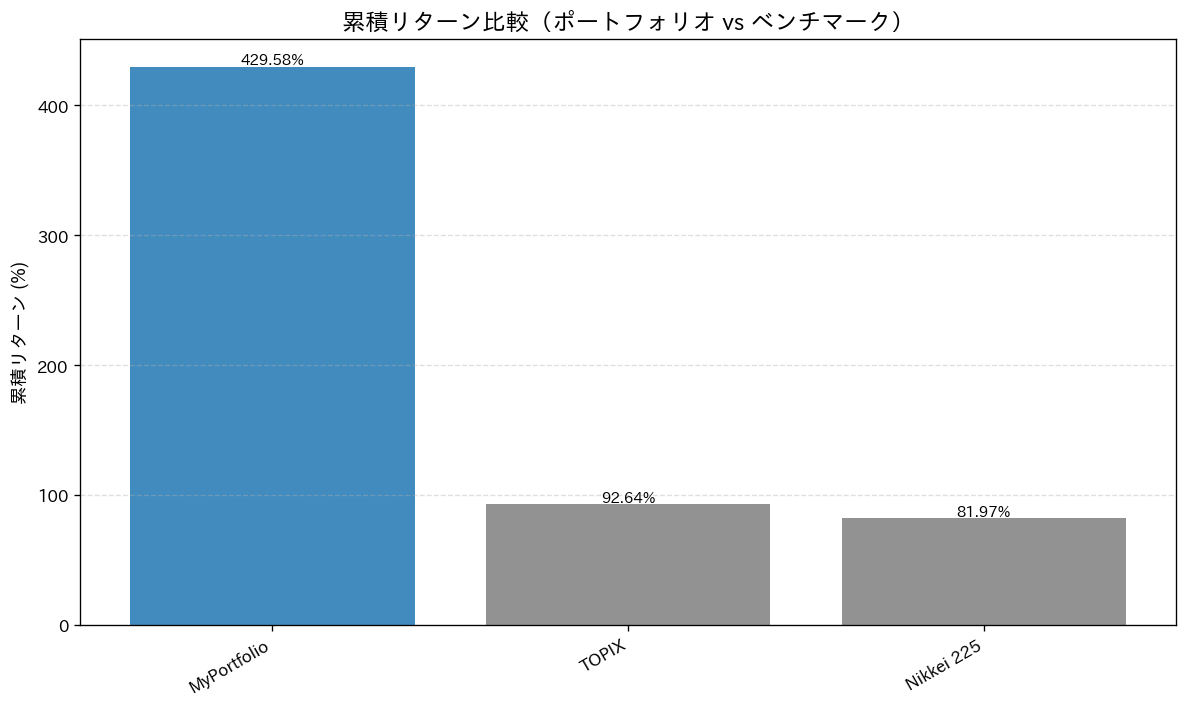

Saved cumulative_return_summary.png


In [158]:
# ===================================================
# 累積リターン比較（棒グラフ）
# ===================================================
FIG_SIZE   = (10, 6)
DPI        = 120
GRID_ALPHA = 0.4
BAR_ALPHA  = 0.85

if not comparison_df.empty:
    df_plot = comparison_df.copy()
    df_plot[_T["col_cum_return"]] = (
        df_plot[_T["col_cum_return"]]
        .astype(str)
        .str.replace("%", "", regex=False)
        .astype(float)
    )
    df_plot = df_plot.sort_values(by=_T["col_cum_return"], ascending=False).reset_index(drop=True)

    labels = df_plot[_T["col_portfolio"]].tolist()
    values = df_plot[_T["col_cum_return"]].tolist()
    x      = np.arange(len(labels))
    colors = ["tab:blue" if l == PORTFOLIO_NAME else "tab:gray" for l in labels]

    fig, ax = plt.subplots(figsize=FIG_SIZE, dpi=DPI)
    bars = ax.bar(x, values, color=colors, alpha=BAR_ALPHA)

    ax.set_title(_T["cum_bar_title"], fontsize=14)
    ax.set_ylabel(_T["cum_bar_ylabel"], fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=GRID_ALPHA)

    for rect, val in zip(bars, values):
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height(),
            f"{val:.2f}%",
            ha="center", va="bottom", fontsize=9
        )

    plt.tight_layout()
    plt.savefig(os.path.join(_out_dir, "cumulative_return_summary.png"))
    plt.show()
    plt.close(fig)
    print("Saved cumulative_return_summary.png")


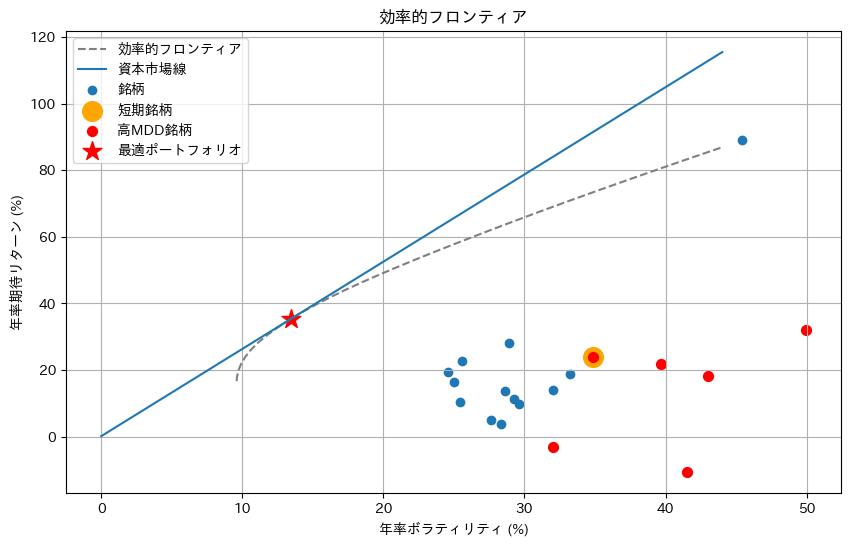

Saved efficient_frontier_cml.png


In [159]:
# ===================================================
# 効率的フロンティア + 資本市場線
# ===================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Efficient Frontier
target_returns = np.linspace(mu.min(), mu.max(), 50)
vols, rets = [], []
for r in target_returns:
    try:
        ef_tmp = EfficientFrontier(mu, S)
        ef_tmp.efficient_return(r)
        r_perf, v_perf, _ = ef_tmp.portfolio_performance()
        vols.append(v_perf)
        rets.append(r_perf)
    except Exception:
        pass

ax.plot(np.array(vols) * 100, np.array(rets) * 100,
        linestyle="--", color="gray", label=_T["ef_frontier"])

# Capital Market Line
cml_x = np.linspace(0, max(vols) * 100, 50)
cml_y = RISK_FREE_RATE * 100 + sharpe * cml_x
ax.plot(cml_x, cml_y, label=_T["ef_cml"])

# 長期銘柄
ax.scatter(
    np.sqrt(np.diag(S.loc[long_term_tickers, long_term_tickers])) * 100,
    mu[long_term_tickers] * 100,
    label=_T["ef_assets"]
)

# 短期銘柄
if short_term_tickers:
    ax.scatter(
        np.sqrt(np.diag(S.loc[short_term_tickers, short_term_tickers])) * 100,
        mu[short_term_tickers] * 100,
        color="orange", s=200, label=_T["ef_short"]
    )

# 高MDD銘柄
if knockout_tickers:
    ax.scatter(
        np.sqrt(np.diag(S.loc[knockout_tickers, knockout_tickers])) * 100,
        mu[knockout_tickers] * 100,
        color="red", s=50, label=_T["ef_highmdd"]
    )

# 最適ポートフォリオ
ax.scatter(volatility * 100, expected_return * 100,
           marker="*", s=200, color="red", label=_T["ef_optimal"])

ax.set_title(_T["ef_title"])
ax.set_xlabel(_T["ef_xlabel"])
ax.set_ylabel(_T["ef_ylabel"])
ax.legend()
ax.grid(True)

plt.savefig(os.path.join(_out_dir, "efficient_frontier_cml.png"), bbox_inches="tight")

plt.show()
plt.close()
print("Saved efficient_frontier_cml.png")


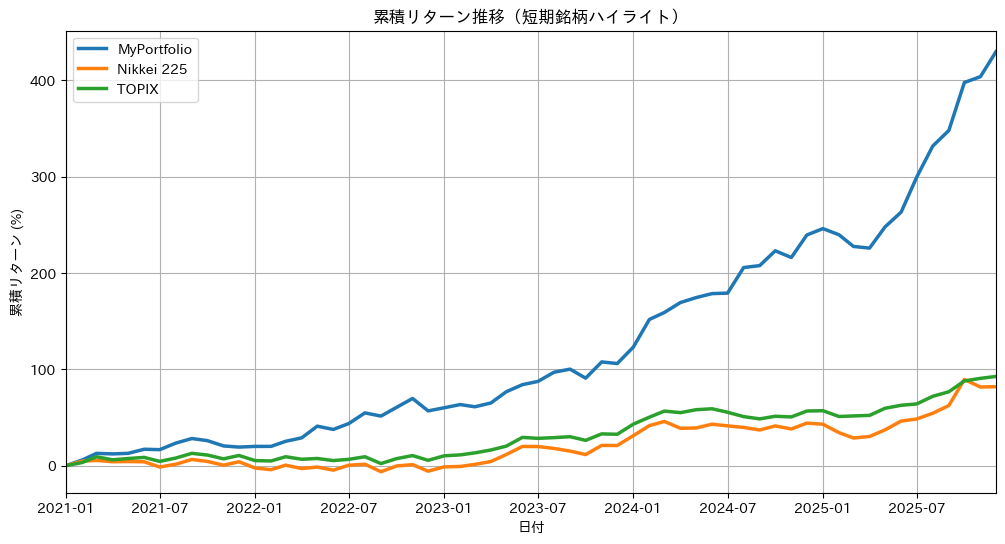

Saved cumulative_returns_comparison.png


In [160]:
# ===================================================
# 累積リターン推移（折れ線グラフ）
# ===================================================
fig, ax = plt.subplots(figsize=(12, 6))

series_map = {PORTFOLIO_NAME: portfolio_returns}
for sym in bench_tickers:
    series_map[benchmark_labels[sym]] = bench_returns[sym].loc[portfolio_returns.index[0]:]

global_min, global_max = None, None

for name, series in series_map.items():
    cum  = (1 + series).cumprod() - 1
    zero = pd.Series([0.0], index=[cum.index[0] - pd.DateOffset(months=1)])
    cum  = pd.concat([zero, cum])

    linestyle = "--" if name in short_term_tickers else "-"
    linewidth = 1.5  if name in short_term_tickers else 2.5

    ax.plot(cum.index, cum * 100, label=name,
            linestyle=linestyle, linewidth=linewidth)

    global_min = cum.index.min() if global_min is None else min(global_min, cum.index.min())
    global_max = cum.index.max() if global_max is None else max(global_max, cum.index.max())

ax.set_title(_T["cum_line_title"])
ax.set_xlabel(_T["date"])
ax.set_ylabel(_T["cum_ret"])
ax.legend()
ax.grid(True)
ax.set_xlim(global_min, global_max)

plt.savefig(os.path.join(_out_dir, "cumulative_returns_comparison.png"), bbox_inches="tight")
plt.show()
plt.close()
print("Saved cumulative_returns_comparison.png")


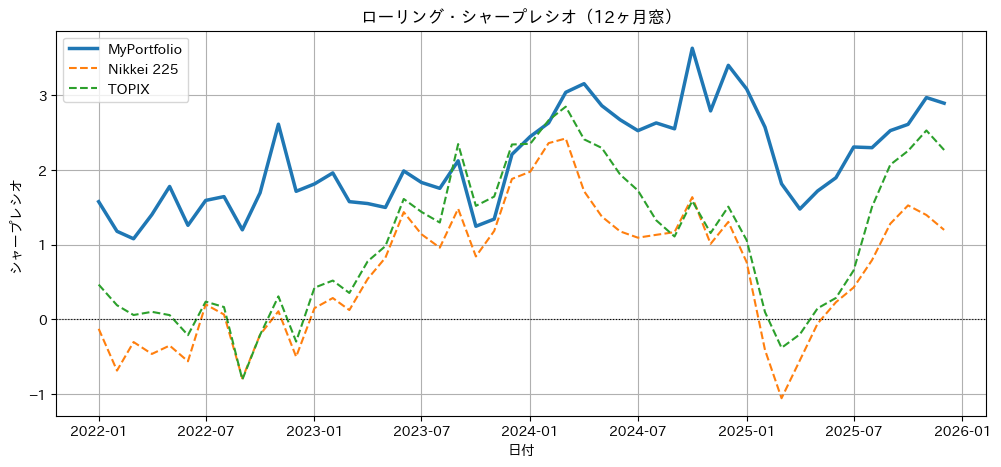

Saved rolling_sharpe.png


In [161]:
# ===================================================
# ローリング・シャープレシオ（12ヶ月窓）
# ===================================================
_window = 12

fig, ax = plt.subplots(figsize=(12, 5))

_roll_pf = (
    portfolio_returns.rolling(_window).mean() /
    portfolio_returns.rolling(_window).std()
) * np.sqrt(12)
ax.plot(_roll_pf.index, _roll_pf, label=PORTFOLIO_NAME, linewidth=2.5)

for sym in bench_tickers:
    _rs = (
        bench_returns[sym].rolling(_window).mean() /
        bench_returns[sym].rolling(_window).std()
    ) * np.sqrt(12)
    ax.plot(_rs.index, _rs, label=benchmark_labels[sym],
            linewidth=1.5, linestyle="--")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_title(_T["roll_title"].format(w=_window))
ax.set_xlabel(_T["date"])
ax.set_ylabel(_T["roll_ylabel"])
ax.legend()
ax.grid(True)

plt.savefig(os.path.join(_out_dir, "rolling_sharpe.png"), bbox_inches="tight")
plt.show()
plt.close()
print("Saved rolling_sharpe.png")

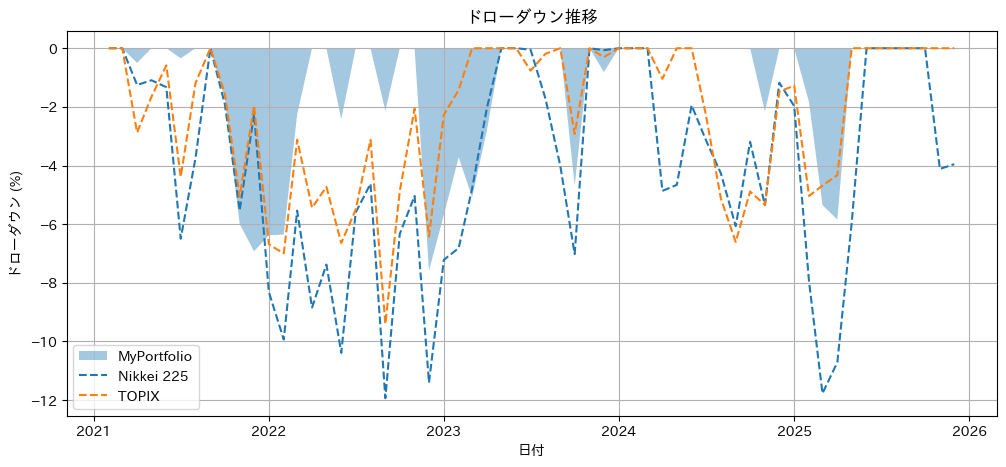

Saved drawdown.png


In [162]:
# ===================================================
# ドローダウン推移
# ===================================================
def _drawdown_series(series: pd.Series) -> pd.Series:
    cum  = (1 + series).cumprod()
    peak = cum.cummax()
    return (cum / peak - 1) * 100

fig, ax = plt.subplots(figsize=(12, 5))

_dd_pf = _drawdown_series(portfolio_returns)
ax.fill_between(_dd_pf.index, _dd_pf, 0,
                alpha=0.4, label=PORTFOLIO_NAME)

for sym in bench_tickers:
    _dd = _drawdown_series(bench_returns[sym].loc[portfolio_returns.index[0]:])
    ax.plot(_dd.index, _dd, label=benchmark_labels[sym],
            linewidth=1.5, linestyle="--")

ax.set_title(_T["dd_title"])
ax.set_xlabel(_T["date"])
ax.set_ylabel(_T["dd_ylabel"])
ax.legend()
ax.grid(True)

plt.savefig(os.path.join(_out_dir, "drawdown.png"), bbox_inches="tight")
plt.show()
plt.close()
print("Saved drawdown.png")


In [163]:
# ===================================================
# 分析結果の保存（日時フォルダ）
# ===================================================
import shutil

# os.makedirs(_out_dir, exist_ok=True)

_save_files = [
    INPUT_JSON_PATH,
    OUTPUT_JSON_PATH,
    "analysis_results.xlsx",
    "resolved_symbols.xlsx",
]

for _f in _save_files:
    if os.path.exists(_f):
        shutil.copy2(_f, os.path.join(_out_dir, _f))
        print(f"  Saved: {_f}")
    else:
        print(f"  Skipped (not found): {_f}")

print(f"\nAll files saved to ./{_out_dir}/")

# ===================================================
# zip 圧縮（Colab 等オンライン環境向け）
# 使用する場合はコメントアウトを外して実行
# ===================================================
# import zipfile
# _zip_path = f"{_out_dir}.zip"
# with zipfile.ZipFile(_zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
#     for _f in _save_files:
#         _fp = os.path.join(_out_dir, _f)
#         if os.path.exists(_fp):
#             zf.write(_fp, arcname=_f)
# print(f"Zip created: {_zip_path}")
# #
# # Google Colab でのダウンロード
# # from google.colab import files
# # files.download(_zip_path)


  Saved: input.json
  Saved: output.json
  Saved: analysis_results.xlsx
  Saved: resolved_symbols.xlsx

All files saved to ./MyPortfolio_2026.05.06_17.05.59/
